In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

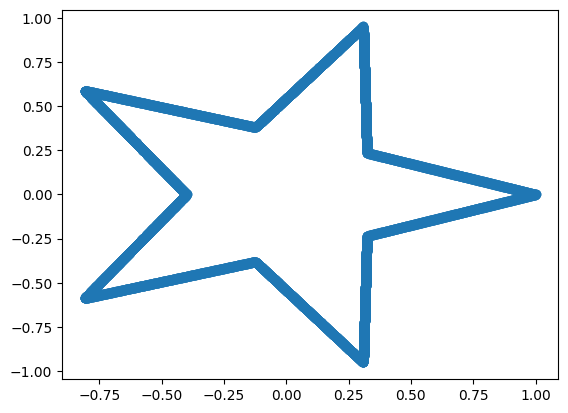

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [38]:
class Config:
    beta_min = 0.01
    beta_max = 2.0
    mode='uniform'

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [39]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [40]:
def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def log_alpha_t(t, config):
    return -0.25 * (config.beta_max - config.beta_min) * t**2 - 0.5 * config.beta_min * t

def alpha_t(t, config):
    return torch.exp(log_alpha_t(t, config))

def std_t(t, config):
    a = alpha_t(t, config)
    return torch.sqrt(1.0 - a**2 + 1e-5)

In [41]:
def loss_weight(t, sigma, config, mode='uniform', eps=1e-4):
    if mode == 'uniform':
        w = torch.ones_like(t)
    elif mode == 'sigma2':
        w = sigma ** 2
    elif mode == 'beta':
        w = beta_t(t, config)
    elif mode == 'inv_sigma2':
        w = 1.0 / torch.clamp(sigma ** 2, min=eps)
        w = torch.clamp(w, min=0.0, max=100.0)
        w = w / w.mean().detach()
    return w


In [42]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        self.mode = self.config.mode

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            a = alpha_t(t, self.config)
            s = std_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = a * batch + s * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            w = loss_weight(t, s, self.config, mode=self.mode)
            per_sample = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        total_loss = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            total_loss.append(loss)
            if n % 100 == 0:
                print(f'Loss: {loss}')
        return total_loss

In [43]:
config = Config()
trainer = VETrainer(config)

In [44]:
losses = {}

In [46]:
losses["base"] = trainer.run()

Loss: 0.45149347653388977
Loss: 0.4472122036933899
Loss: 0.46027690963745116
Loss: 0.45479246640205384
Loss: 0.4622700008869171
Loss: 0.44165602884292604
Loss: 0.4421626304626465
Loss: 0.45654951395988463
Loss: 0.43789443340301515
Loss: 0.43483542313575746
Loss: 0.4455836612701416
Loss: 0.43875871505737307
Loss: 0.44707261090278627
Loss: 0.4339428593635559
Loss: 0.44759784874916075
Loss: 0.43861513571739197
Loss: 0.43412310009002686
Loss: 0.44595024518966675
Loss: 0.4376350271224976
Loss: 0.4376484834194183


In [47]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            std = std_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / std

            drift = (0.5 * beta * x + beta * score) * dt
            diffusion = torch.sqrt(beta) * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [48]:
samples = sample(trainer.model, trainer.config, 1000)

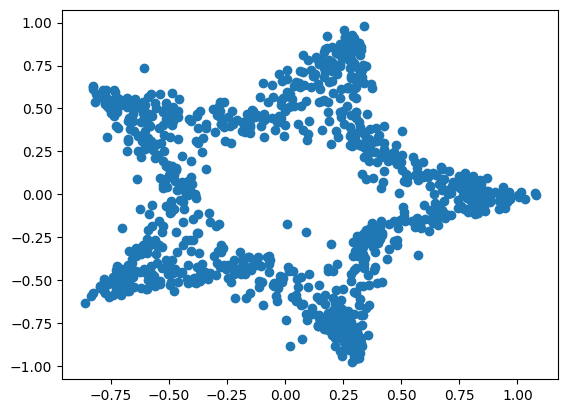

In [49]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

# попробуем разные виды взвешивания лоссов

сделаем через взвешивать через $\sigma^2$

In [50]:
config = Config()
config.mode = 'sigma2'
trainer = VETrainer(config)

In [51]:
losses["sigma2"] = trainer.run()

Loss: 0.2411013031721115
Loss: 0.07550506308078767
Loss: 0.0740369099855423
Loss: 0.07552952251434326
Loss: 0.07473013201951981
Loss: 0.07173821449279785
Loss: 0.07251856755018234
Loss: 0.07606114820241928
Loss: 0.0755682295680046
Loss: 0.07458738256692886
Loss: 0.07300027977228164
Loss: 0.07312058618068695
Loss: 0.07230920640230179
Loss: 0.07126294176578522
Loss: 0.07259273724555969
Loss: 0.07387405459880829
Loss: 0.07081751216650009
Loss: 0.07248710777759552
Loss: 0.07364958440065383
Loss: 0.07221264168024064


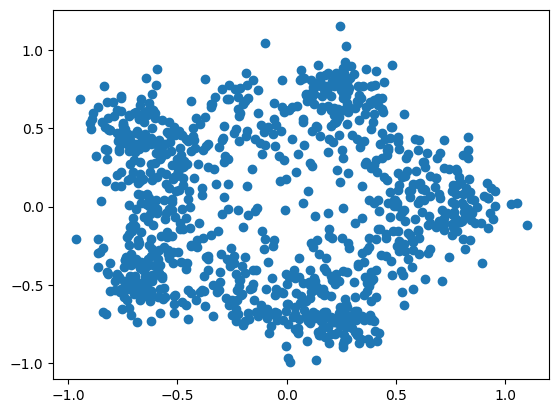

In [52]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Мне кажется по качеству стало сильно хуже, контур звезды хуже заметен

попробуем теперь beta

In [53]:
config = Config()
config.mode = 'beta'
trainer = VETrainer(config)

In [54]:
losses["beta"] = trainer.run()

Loss: 0.956151410484314
Loss: 0.3546313568115234
Loss: 0.34763918151855466
Loss: 0.34595480680465696
Loss: 0.3445513423919678
Loss: 0.34459827766418455
Loss: 0.3305009125709534
Loss: 0.33966701922416687
Loss: 0.3251350255489349
Loss: 0.33258347177505493
Loss: 0.3314358248710632
Loss: 0.33496460757255553
Loss: 0.3285946447849274
Loss: 0.333101011800766
Loss: 0.3259517293930054
Loss: 0.33200909991264344
Loss: 0.3298208181858063
Loss: 0.3325769215106964
Loss: 0.32750685415267944
Loss: 0.3377309188365936


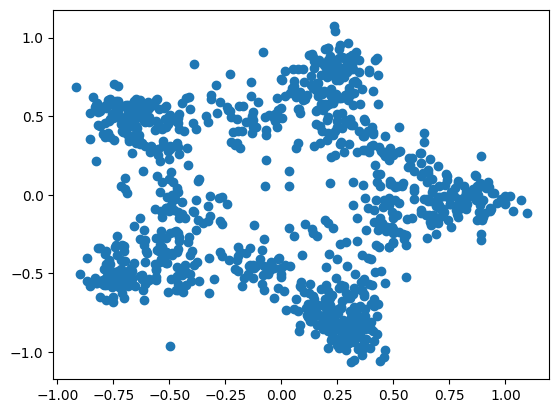

In [55]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

теперь попробуем через $\frac{1}{\sigma^2}$

In [56]:
config = Config()
config.mode = 'inv_sigma2'
trainer = VETrainer(config)

In [57]:
losses["inv_sigma2"] = trainer.run()

Loss: 1.0313962405204773
Loss: 0.8192587100982666
Loss: 0.7993907461166382
Loss: 0.8073528930664062
Loss: 0.7974868990898132
Loss: 0.7637276643753051
Loss: 0.7037385166168213
Loss: 0.7012190190315246
Loss: 0.7132905388832093
Loss: 0.716365573978424
Loss: 0.725626215839386
Loss: 0.7211711304664612
Loss: 0.7077752351760864
Loss: 0.7008978251457214
Loss: 0.6646283493041992
Loss: 0.6840115830421448
Loss: 0.6611296556472779
Loss: 0.6837201913833618
Loss: 0.7270247889518737
Loss: 0.6575381021499633


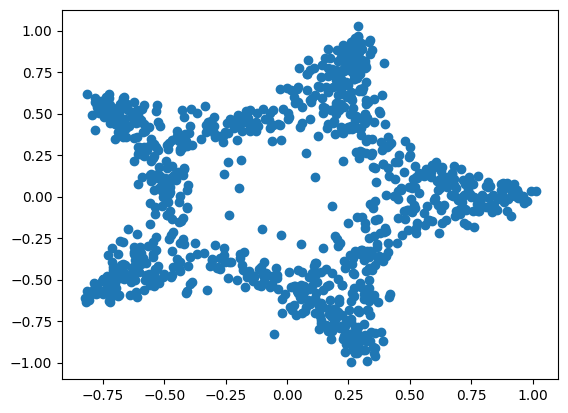

In [58]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Сравним графики лоссов

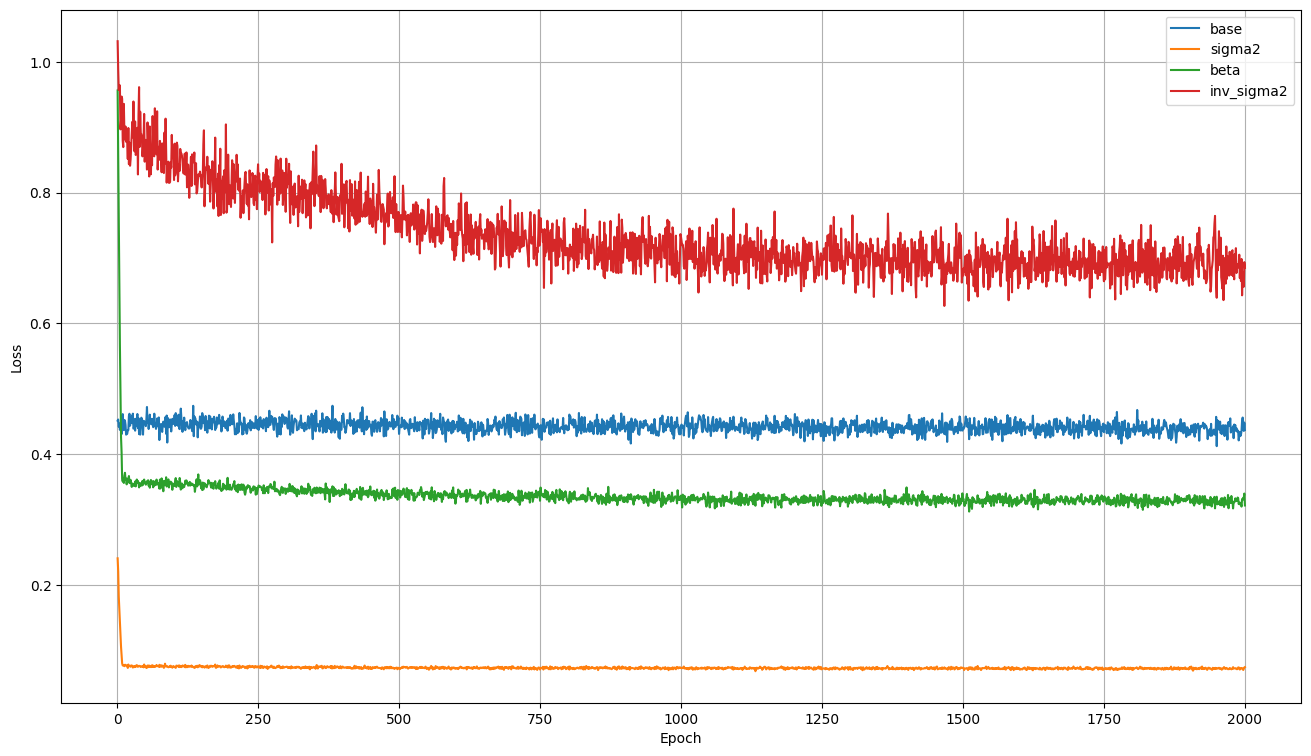

In [59]:
plt.figure(figsize=(16,9))
epochs = range(1, 2001)
for name, loss in losses.items():
    plt.plot(epochs, loss, label=name)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend()
plt.show()

по качеству лучшим оказалось базовый лосс и лосс со взвешиванием через $\frac{1}{\sigma^2}$. Она Наиболее выраженные контуры звездочки. Остальные кандидаты показали себя хуже, в особенности с $\beta$ и $\sigma^2$. По лоссу лучшим оказалась модель с $\sigma^2$

# сравним расписания

In [60]:
def cosine_alpha_bar_t(t, s=0.008):
    t = torch.clamp(t, 0.0, 1.0)
    f_t = torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2
    f_0 = torch.cos(torch.tensor(s / (1 + s) * torch.pi / 2, device=t.device)) ** 2
    return f_t / f_0


def cosine_alpha_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(alpha_bar, min=1e-6, max=1.0))


def cosine_std_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(1.0 - alpha_bar, min=1e-6, max=1.0))


def cosine_beta_t(t, config=None, s=0.008):
    t = torch.clamp(t, 1e-5, 1.0 - 1e-5)
    u = (t + s) / (1 + s)
    beta = (torch.pi / (1 + s)) * torch.tan(u * torch.pi / 2)
    return torch.clamp(beta, max=50.0)


In [61]:
class VETrainer1():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        self.mode = self.config.mode

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            a = cosine_alpha_t(t, self.config)
            s = cosine_std_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = a * batch + s * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            w = loss_weight(t, s, self.config, mode=self.mode)
            per_sample = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        total_loss = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            total_loss.append(loss)
            if n % 100 == 0:
                print(f'Loss: {loss}')
        return total_loss

In [62]:
def sample1(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = cosine_beta_t(t_tensor, config)
            std = cosine_std_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / std

            drift = (0.5 * beta * x + beta * score) * dt
            diffusion = torch.sqrt(torch.clamp(beta, min=1e-5)) * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [68]:
config = Config()
trainer = VETrainer1(config)

In [69]:
losses['sigma2_cosine'] = trainer.run()

Loss: 0.8996378660202027
Loss: 0.32045637679100036
Loss: 0.3275931845188141
Loss: 0.30136147232055666
Loss: 0.3168520544528961
Loss: 0.2897170323371887
Loss: 0.3085512934684753
Loss: 0.301406462430954
Loss: 0.2961253468990326
Loss: 0.3111802776813507
Loss: 0.2931577144622803
Loss: 0.3085328285694122
Loss: 0.3007471410751343
Loss: 0.2866003242969513
Loss: 0.29141199049949645
Loss: 0.27910951209068297
Loss: 0.28837537603378294
Loss: 0.29753663544654846
Loss: 0.2940211399078369
Loss: 0.2948506409645081


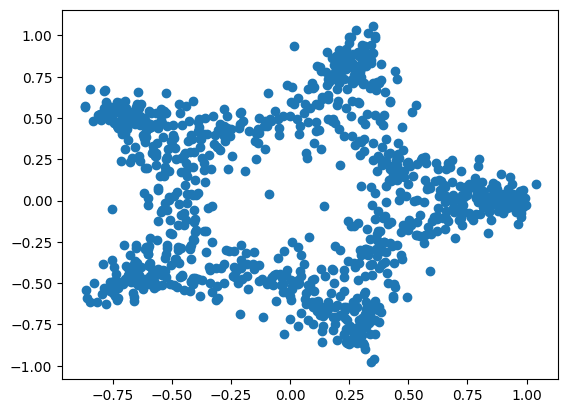

In [70]:
samples = sample1(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

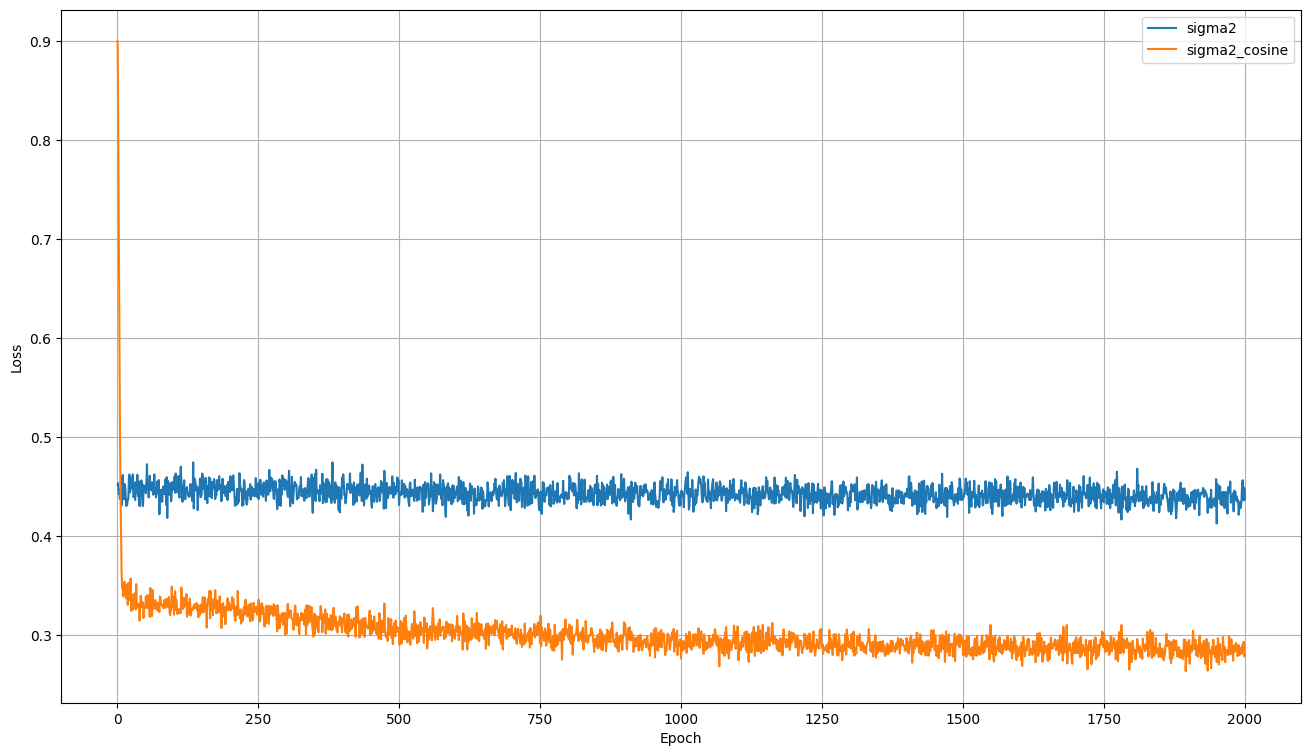

In [71]:
plt.figure(figsize=(16,9))
epochs = range(1, 2001)
plt.plot(epochs, losses['base'], label='sigma2')
plt.plot(epochs, losses['sigma2_cosine'], label='sigma2_cosine')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()